<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-PHUONG128/Churn-Prediction/blob/main/Phan_tich_KQ_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chuẩn bị dữ liệu

In [ ]:
from google.colab import files

print("Upload file thứ 1:")
uploaded1 = files.upload()

print("Upload file thứ 2:")
uploaded2 = files.upload()

Upload file thứ 1:


Saving bank_churn_dataset.csv to bank_churn_dataset.csv
Upload file thứ 2:


Saving predictions_logistic_regression.csv to predictions_logistic_regression.csv


In [ ]:
import pandas as pd

# 1. Đọc dữ liệu từ 2 file csv
df1 = pd.read_csv('bank_churn_dataset.csv')
df2 = pd.read_csv('predictions_logistic_regression.csv')

# 2. Ghép 2 file dựa vào cột 'id'
# how='inner' Chỉ giữ những hàng mà cả 2 file đều có chung id.,
df_merged = pd.merge(df1, df2, on='id', how='inner')

# 3. Kiểm tra kết quả
print(df_merged.head())

# 4. Xuất ra file csv mới
df_merged.to_csv('mapping_raw_model.csv', index=False)

   id      full_name_x  credit_sco  gender  age  \
0   1      Đặng Văn Vũ         725    male   55   
1  11  Nguyễn Thị Linh         724  female   34   
2  14  Trần Hoàng Khoa         584    male   44   
3  16     Phạm Kim Nam         747    male   49   
4  25    Hoàng Minh Tú         788    male   60   

                      occupation    balance  monthly_ir  \
0           Chủ Doanh nghiệp nhỏ  177306004   121000000   
1  Nhân viên văn phòng/Công chức   57319508    21000000   
2                        Hưu trí   22350304    12000000   
3           Kỹ sư/Chuyên viên IT   78554326    57000000   
4               Quản lý/Lãnh đạo  145014383   107000000   

                   address  origin_province  ...  customer_segment  \
0       Phường An Hội (BT)  TP. Hồ Chí Minh  ...          Priority   
1      Phường 2 (Tân Bình)  TP. Hồ Chí Minh  ...          Emerging   
2  Phường Quang Trung (GV)          Long An  ...              Mass   
3  Phường Quang Trung (GV)           Hà Nội  ...          

# Phân loại & đánh giá kết quả dự đoán

In [ ]:
# 1. Phân loại và gắn nhãn dữ liệu

import pandas as pd
import numpy as np

# Giả sử cột thực tế là 'actual_churn' và cột dự đoán là 'predicted_churn'
# Tạo các điều kiện logic
conditions = [
    (df_merged['actual_churn'] == 0) & (df_merged['predicted_churn'] == 0), # TN
    (df_merged['actual_churn'] == 1) & (df_merged['predicted_churn'] == 1), # TP
    (df_merged['actual_churn'] == 0) & (df_merged['predicted_churn'] == 1), # FP
    (df_merged['actual_churn'] == 1) & (df_merged['predicted_churn'] == 0)  # FN
]

# Đặt tên tương ứng cho các điều kiện
choices = ['True Negative', 'True Positive', 'False Positive', 'False Negative']

# Tạo cột mới 'confusion_category'
df_merged['confusion_category'] = np.select(conditions, choices, default='Unknown')

# Xem kết quả 5 dòng đầu
print(df_merged[['id', 'actual_churn', 'predicted_churn', 'confusion_category']].head())

   id  actual_churn  predicted_churn confusion_category
0   1             0                0      True Negative
1  11             0                0      True Negative
2  14             0                1     False Positive
3  16             0                0      True Negative
4  25             0                0      True Negative


In [ ]:
# 2. Thống kê số lượng (Summary Table)
# Để biết tổng quát model hoạt động ra sao.

summary = df_merged['confusion_category'].value_counts().reset_index()
summary.columns = ['Category', 'Count']

# Tính thêm tỷ lệ %
summary['Percentage'] = (summary['Count'] / len(df_merged) * 100).round(2)
print(summary)

         Category  Count  Percentage
0   True Negative   9389       58.68
1  False Positive   3731       23.32
2   True Positive   2407       15.04
3  False Negative    473        2.96


**1. Phân tích các chỉ số cơ bản**

Từ bảng kết quả, chúng ta có tổng số tập dữ liệu (dataset) đang đánh giá là: 16,000 khách hàng (bằng tổng của cột Count).

*   True Negative (TN) - 58.68% (9389): Phần lớn khách hàng được dự đoán chính xác là sẽ tiếp tục gắn bó với ngân hàng.
*   False Positive (FP) - 23.32% (3731): Một tỷ lệ khá lớn khách hàng bị nhận diện nhầm là sẽ rời bỏ (báo động giả).
*   True Positive (TP) - 15.04% (2407): Mô hình đã "bắt" trúng được hơn 2.4 ngàn khách hàng thực sự có ý định rời bỏ.
*   False Negative (FN) - 2.96% (473): Số lượng khách hàng bị bỏ lọt (thực tế rời bỏ nhưng dự đoán là an toàn) rất thấp.


**2. Đánh giá chất lượng mô hình (Tính toán các Metric quan trọng)**

Chỉ nhìn vào bảng trên chưa đủ, chúng ta cần tính các "tỷ lệ vàng" trong Machine Learning để thấy rõ bức tranh:

*   Độ chính xác tổng thể (Accuracy):$$Accuracy = \frac{TP + TN}{Total} = \frac{2407 + 9389}{16000} \approx 73.7\%$$Mô hình đoán đúng được gần 74% tổng số trường hợp. Tuy nhiên, với bài toán Churn, Accuracy không phải là chỉ số quan trọng nhất.
*   Độ nhạy (Recall / True Positive Rate):$$Recall = \frac{TP}{TP + FN} = \frac{2407}{2407 + 473} \approx 83.5\%$$Đây là một điểm rất sáng của mô hình! Trong số tất cả những khách hàng thực sự đã rời bỏ, mô hình của bạn đã nhận diện thành công đến 83.5%. Tỷ lệ bỏ lọt (FN) rất thấp.
*   Độ chuẩn xác (Precision):$$Precision = \frac{TP}{TP + FP} = \frac{2407}{2407 + 3731} \approx 39.2\%$$Đây là điểm cần lưu ý. Trong số tất cả những người mà mô hình cảnh báo là sẽ rời bỏ (6138 người), thì chỉ có khoảng 39% là thực sự rời đi. Hơn 60% còn lại là báo động giả (FP).

**3. Nhận định dưới góc độ Kinh doanh (Business Insight)**
Mô hình Logistic Regression của bạn đang có xu hướng "thà giết lầm còn hơn bỏ sót" (High Recall, Low Precision).

*   Ưu điểm: Rất tốt cho ngân hàng nếu mục tiêu tối thượng là giữ chân khách hàng bằng mọi giá. Ngân hàng sẽ không bị bất ngờ trước sự ra đi của khách hàng vì mô hình đã quét được hầu hết.
*   Nhược điểm: Phung phí tài nguyên Marketing/Chăm sóc khách hàng. Ngân hàng sẽ phải đổ tiền (gọi điện, tặng quà, giảm lãi suất) cho 3731 khách hàng (False Positive) vốn dĩ không hề có ý định rời đi.




# Tìm nguyên nhân dự đoán sai
-> Phân tích nhóm False Positive (Báo động giả - 23.32%)

## 1. Giả thuyết 1: Khách hàng "ngủ đông" (Passive Loyalists).
Đây là những người có tenure_years (số năm gắn bó) rất cao nhưng engagement_score thấp. Họ giữ tài khoản chỉ để nhận lương hoặc trả góp, không mặn mà với các dịch vụ mới nhưng cũng không có ý định đóng tài khoản.



### Bước 1: Trực quan hóa sự phân bổ (Boxplot) của "Số năm gắn bó" và "Điểm tương tác"





/tmp/ipykernel_51087/3409999350.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='confusion_category', y='tenure_ye', data=df_merged, palette='Set2')
/tmp/ipykernel_51087/3409999350.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='confusion_category', y='engagement_score', data=df_merged, palette='Set2')


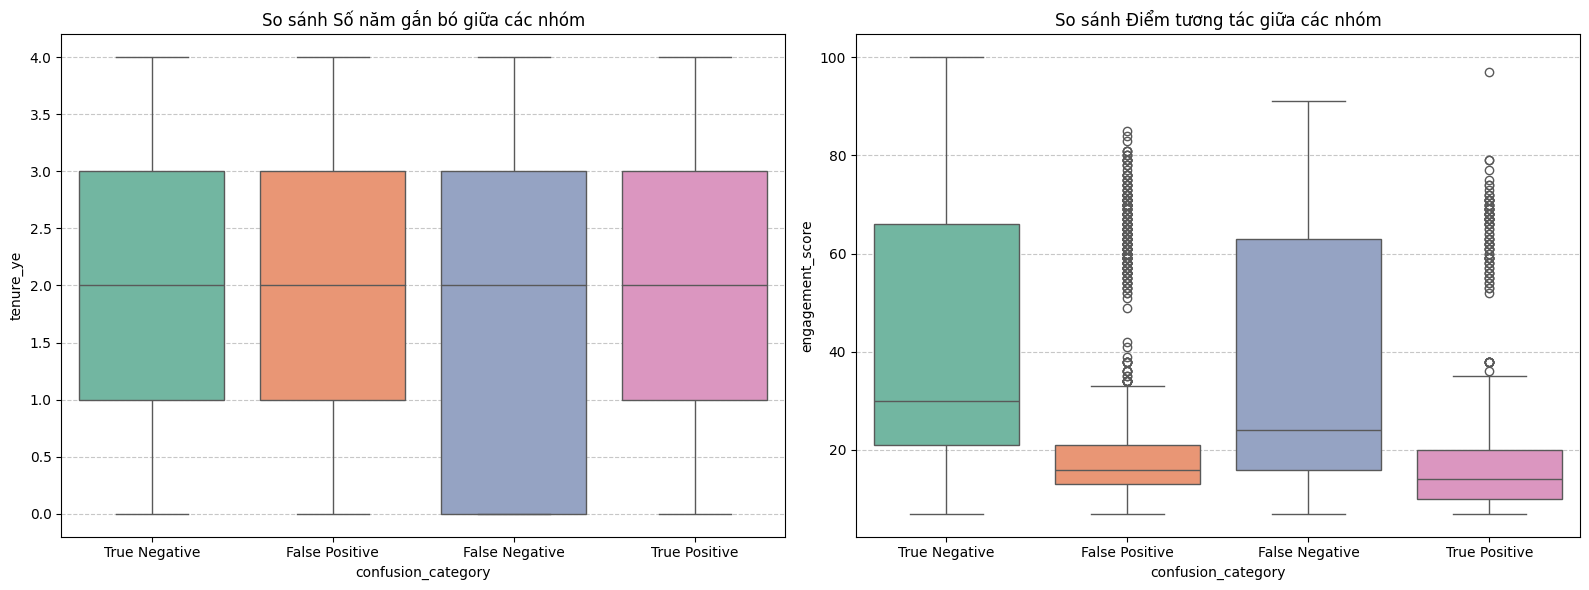

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(16, 6))

# Vẽ biểu đồ Tenure_years
plt.subplot(1, 2, 1)
sns.boxplot(x='confusion_category', y='tenure_ye', data=df_merged, palette='Set2')
plt.title('So sánh Số năm gắn bó giữa các nhóm')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Vẽ biểu đồ Engagement_score
plt.subplot(1, 2, 2)
sns.boxplot(x='confusion_category', y='engagement_score', data=df_merged, palette='Set2')
plt.title('So sánh Điểm tương tác giữa các nhóm')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Bước 2: So sánh chỉ số trung bình (Statistical Summary)

In [ ]:
# Tạo bảng so sánh
passive_check = df_merged.groupby('confusion_category').agg({
    'tenure_ye': ['mean', 'median'],
    'engagement_score': ['mean', 'median'],
    'balance': ['mean', 'median'],
    'id': 'count'
}).reset_index()

print("Bảng thống kê kiểm chứng giả thuyết Passive Loyalists:")
print(passive_check)


Bảng thống kê kiểm chứng giả thuyết Passive Loyalists:
  confusion_category tenure_ye        engagement_score              balance  \
                          mean median             mean median          mean   
0     False Negative  1.716702    2.0        35.619450   24.0  3.370694e+07   
1     False Positive  1.835165    2.0        19.447601   16.0  2.055035e+07   
2      True Negative  1.788369    2.0        40.158590   30.0  9.113576e+07   
3      True Positive  1.697549    2.0        17.245118   14.0  1.608842e+07   

                 id  
       median count  
0  27292644.0   473  
1  17006737.0  3731  
2  56839949.0  9389  
3  12106909.0  2407  


**Cách đọc kết quả:**
Nếu `tenure_years` của FP xấp xỉ TN (ví dụ: cả hai đều > 5 năm) nhưng `engagement_score` của FP lại thấp như TP (ví dụ: < 30 điểm) => Giả thuyết đúng.

**Kết luận giả thuyết 1 đúng**: Nhóm FP sẽ tạo thành một "quần thể" trung gian: Họ có hồ sơ lịch sử của một khách hàng trung thành (Tenure cao, Balance ổn định) nhưng lại có hành vi hiện tại của một khách hàng sắp rời bỏ (Engagement thấp).

**Giải pháp kỹ thuật**:Để giảm FP ở nhóm này, bạn có thể cần tạo thêm một feature là loyalty_engagement_ratio (tỷ lệ tương tác trên mỗi năm gắn bó) hoặc tăng trọng số (weight) cho biến tenure_years trong model.

## 2.	Giả thuyết 2: Sản phẩm neo giữ (Product Lock-in).
Dù active_member là 0 (không tích cực), nhưng họ có thể đang có một khoản vay hoặc sổ tiết kiệm chưa tất toán (balance cao). Model có thể chưa trọng số đủ mạnh cho cột balance hoặc loyalty_level.


### Bước 1: Lọc dữ liệu nhóm "Không tích cực" và so sánh Số dư (balance)
Chúng ta chỉ xét những khách hàng có active_member == 0, sau đó so sánh số dư giữa nhóm bị dự báo nhầm (FP) và nhóm dự báo đúng (TP).

In [ ]:
import pandas as pd
import numpy as np

# 1. Lọc riêng nhóm khách hàng KHÔNG TÍCH CỰC
inactive_df = df_merged[df_merged['active_member'] == 0]

# 2. Tính toán số dư trung bình và trung vị của nhóm này theo từng danh mục Confusion Matrix
lockin_balance = inactive_df.groupby('confusion_category').agg({
    'balance': ['mean', 'median'],
    'id': 'count'
}).reset_index()

print("Bảng thống kê số dư của riêng nhóm KHÔNG TÍCH CỰC (active_member = 0):")
print(lockin_balance)

Bảng thống kê số dư của riêng nhóm KHÔNG TÍCH CỰC (active_member = 0):
  confusion_category       balance                id
                              mean      median count
0     False Negative  4.311737e+07  37171931.0   319
1     False Positive  2.136072e+07  17789070.0  3495
2      True Negative  1.087995e+08  71784847.5  6428
3      True Positive  1.645025e+07  12447705.0  2319


**Cách đọc kết quả**:
Nếu balance (mean/median) của nhóm FP cao hơn hẳn nhóm TP $\rightarrow$ Giả thuyết đúng.

**Kết quả:**
Giả thuyết không đúng vì theo dữ liệu thực tế:

*   Nhóm False Positive (FP) có số dư rất thấp (trung bình chỉ ~21.3 triệu).
*   Nhóm này có hồ sơ (profile) rất giống với nhóm True Positive (TP) (những người thực sự rời bỏ): Cả hai đều "Không tích cực" và có "Số dư thấp" (~16 triệu đến 21 triệu).

-> Model dự đoán nhóm FP sẽ rời đi là hoàn toàn có cơ sở logic (vì họ không hoạt động và tiền trong tài khoản cũng gần cạn). Tuy nhiên, họ lại KHÔNG rời đi. Điều này chứng tỏ "Sản phẩm neo giữ" (Product Lock-in) của nhóm FP không phải là Số dư (Balance).








### Bước 2: Kiểm tra yếu tố phân lớp trung thành (loyalty_level)
loyalty_level thường là biến phân loại (ví dụ: Gold, Silver, Bronze hoặc Thân thiết, VIP...). Chúng ta sẽ xem tỷ lệ các cấp độ trung thành này phân bổ như thế nào trong nhóm không tích cực.


In [ ]:
# Tạo bảng chéo (Crosstab) tính tỷ lệ % loyalty_level trong từng nhóm kết quả
loyalty_pct = pd.crosstab(inactive_df['confusion_category'], inactive_df['loyalty_level'], normalize='index') * 100

print("Tỷ lệ % các cấp độ trung thành của KH không tích cực:")
print(loyalty_pct.round(2))

Tỷ lệ % các cấp độ trung thành của KH không tích cực:
loyalty_level       Bronze  Silver
confusion_category                
False Negative       97.49    2.51
False Positive       99.71    0.29
True Negative        87.73   12.27
True Positive        99.78    0.22


**Cách đọc kết quả:**
Nếu ở dòng False Positive (FP), tỷ lệ các hạng khách hàng cao cấp (VIP/Gold) chiếm phần lớn, trong khi ở dòng True Positive (TP) chủ yếu là hạng phổ thông (Standard/Bronze) $\rightarrow$ Giả thuyết đúng. Khách hàng hạng cao cấp dù lười tương tác nhưng họ có sự gắn kết ngầm với ngân hàng, model đang bỏ qua biến loyalty_level này.

**Kết quả:**
Giả thuyết sai. Khách hàng phần lớn ở hạng phổ thông.

## 3. Giả thuyết 3: Nhiễu từ nhóm Demographic.

Có thể một phân khúc occupation (nghề nghiệp) hoặc age (độ tuổi) nhất định có hành vi ít tương tác nhưng tỷ lệ rời bỏ tự nhiên lại rất thấp.

In [ ]:
import pandas as pd

# 1. Chia nhóm tuổi thành các khoảng để dễ quan sát
df_merged['age_group'] = pd.cut(df_merged['age'], bins=[0, 25, 35, 50, 100],
                                labels=['Under 25', '25-35', '35-50', 'Above 50'])

# 2. Kiểm tra tỷ lệ lỗi theo Nhóm tuổi, Giới tính và Nghề nghiệp
demo_features = ['gender', 'age_group', 'occupation', 'risk_segment']

for feature in demo_features:
    print(f"\n=== Tỷ lệ % Confusion Category theo {feature} ===")
    # Tính tỷ lệ phần trăm theo từng dòng (index)
    crosstab_res = pd.crosstab(df_merged[feature], df_merged['confusion_category'], normalize='index') * 100
    print(crosstab_res.round(2))


=== Tỷ lệ % Confusion Category theo gender ===
confusion_category  False Negative  False Positive  True Negative  \
gender                                                              
female                        3.24           23.21          58.45   
male                          2.68           23.42          58.90   

confusion_category  True Positive  
gender                             
female                      15.10  
male                        14.99  

=== Tỷ lệ % Confusion Category theo age_group ===
confusion_category  False Negative  False Positive  True Negative  \
age_group                                                           
Under 25                      3.89           22.46          46.41   
25-35                         2.70           26.45          52.67   
35-50                         3.01           24.57          56.93   
Above 50                      2.96           20.98          63.24   

confusion_category  True Positive  
age_group                    

**Cách đọc kết quả:**
Nếu ở một hàng cụ thể (ví dụ: occupation = 'Student' hoặc age_group = 'Under 25') có tỷ lệ False Positive vọt lên rất cao (>40%) $\rightarrow$ Model đang bị nhiễu do phân lớp dữ liệu nhân khẩu học chưa cân bằng.

**Kết quả:**
Giới tính không gây nhiễu. Sai số tập trung nặng ở Nghề nghiệp và Phân lớp rủi ro: Nhóm "Nội trợ/Sinh viên", "Lao động phổ thông", "Hưu trí" và Rủi ro "Medium" bị model báo động giả (FP) cực cao (39% - 45%). Ngược lại, nhóm Quản lý và Chủ doanh nghiệp có tỷ lệ an toàn (TN) tuyệt đối.
